# Scaffold × Model Summary Plots

Six figures distilling the scaffold × model × cost interaction from HAL data. Nothing is saved to disk — rendered inline only.

1. **Spread vs. capability** — does scaffold matter less for stronger models?
2. **Dumbbell** — min/max accuracy across scaffolds, per model, per benchmark.
3. **Rank slope graph** — model rank under scaffold A vs. scaffold B.
4. **Cost of bad scaffold** — cheapest model+best-scaffold vs cheapest model+worst-scaffold to hit a target.
5. **Variance decomposition** — % of accuracy variance explained by model / scaffold / interaction.
6. **Claude-harness within-model deltas** — is Anthropic's harness systematically helpful?

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.special import logit, expit
from scipy.stats import pearsonr, spearmanr

HAL = Path.cwd() / "hal_data"

BENCHMARKS = [
    ("swe_bench_mini_verified.csv", "SWE-bench Mini Verified", "Primary Model"),
    ("gaia.csv",                   "GAIA",                    "Primary Model"),
    ("core_bench_hard.csv",        "CORE-bench Hard",         "Primary Model"),
    ("tau_bench_airline.csv",      "TAU-bench Airline",       "Primary Model"),
    ("scicode.csv",                "SciCode",                 "Primary Model"),
    ("online_mine_2_web.csv",      "Online Mind2Web",         "Primary Model"),
    ("sci_agent_bench.csv",        "SciAgentBench",           "Models"),
    ("usaco.csv",                  "USACO",                   "Primary Model"),
]

def parse_pct(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r"([\d.]+)%", str(s))
    return float(m.group(1)) if m else np.nan

def parse_cost(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r"\$?([\d.,]+)", str(s).replace(",", ""))
    return float(m.group(1)) if m else np.nan

def clean_scaffold(s):
    if pd.isna(s):
        return s
    return re.sub(r"\s*Pareto optimal\s*", "", str(s)).strip()

def normalize_model(s):
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = re.sub(r"\s+High\b", "", s)
    s = re.sub(r"\s*\(.*?\)", "", s)
    return s.strip()

def logit_score(pct):
    p = np.clip(pct / 100.0, 0.005, 0.995)
    return logit(p)

def pct_formatter():
    def fmt(x, pos):
        pct = expit(x) * 100
        return f"{pct:.0f}%" if pct >= 10 else f"{pct:.1f}%"
    return mticker.FuncFormatter(fmt)

def load_hal(filename, model_col="Primary Model"):
    df = pd.read_csv(HAL / filename, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    if "Models" in df.columns and model_col not in df.columns:
        model_col = "Models"
    df = df.rename(columns={model_col: "Model"})
    df["accuracy"] = df["Accuracy"].apply(parse_pct)
    df["cost"]     = df["Cost (USD)"].apply(parse_cost) if "Cost (USD)" in df.columns else np.nan
    df["scaffold"] = df["Scaffold"].apply(clean_scaffold)
    df["model_norm"] = df["Model"].apply(normalize_model)
    df = df.dropna(subset=["accuracy", "model_norm"])
    df = df[(df["accuracy"] > 0) & (df["accuracy"] < 100)]
    df = df.sort_values("accuracy", ascending=False).drop_duplicates(["scaffold", "model_norm"], keep="first")
    return df.reset_index(drop=True)

# Long-format table of every (benchmark, scaffold, model) row
frames = []
for fname, title, mcol in BENCHMARKS:
    try:
        d = load_hal(fname, mcol)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        continue
    d["benchmark"] = title
    frames.append(d[["benchmark", "scaffold", "model_norm", "accuracy", "cost"]])

long = pd.concat(frames, ignore_index=True)
long["logit"] = logit_score(long["accuracy"].values)
print(f"loaded {len(long)} (benchmark, scaffold, model) rows across {long['benchmark'].nunique()} benchmarks")
long.head()

loaded 174 (benchmark, scaffold, model) rows across 8 benchmarks


,benchmark,scaffold,model_norm,accuracy,cost,logit
0,SWE-bench Mini Verified,SWE-Agent,Claude Sonnet 4.5,72.0,463.90,0.944462
1,SWE-bench Mini Verified,SWE-Agent,Claude Opus 4.1,61.0,1351.35,0.447312
2,SWE-bench Mini Verified,SWE-Agent,o4-mini Low,54.0,259.20,0.160343
3,SWE-bench Mini Verified,SWE-Agent,Claude-3.7 Sonnet,54.0,388.88,0.160343
4,SWE-bench Mini Verified,SWE-Agent,o4-mini,50.0,248.46,0.000000


## 1. Scaffold spread vs. model capability

For each (benchmark, model), spread = max−min accuracy across scaffolds (in logit units). X axis = the model's mean accuracy across benchmarks (capability proxy). A negative slope would mean scaffold sensitivity shrinks as models get stronger.

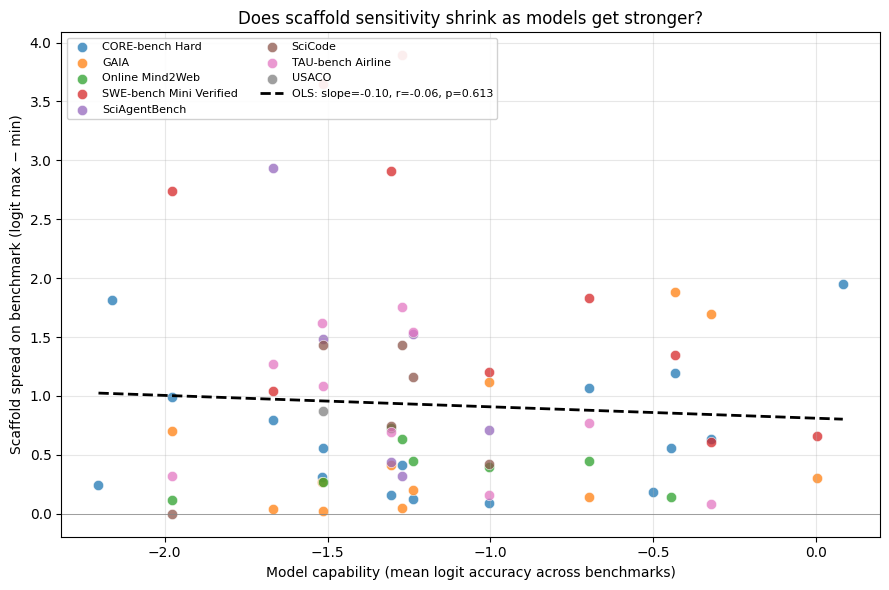

In [3]:
# capability proxy: mean logit accuracy across all (benchmark, scaffold) rows for that model
cap = long.groupby("model_norm")["logit"].mean().rename("capability")

# spread per (benchmark, model)
grp = long.groupby(["benchmark", "model_norm"])["logit"]
spread = (grp.max() - grp.min()).rename("spread")
n_scaff = grp.count().rename("n")
sdf = pd.concat([spread, n_scaff], axis=1).reset_index()
sdf = sdf[sdf["n"] >= 2].merge(cap, left_on="model_norm", right_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
benches = sorted(sdf["benchmark"].unique())
cmap = plt.get_cmap("tab10")
for i, b in enumerate(benches):
    sub = sdf[sdf["benchmark"] == b]
    ax.scatter(sub["capability"], sub["spread"], color=cmap(i % 10),
               label=b, alpha=0.75, s=55, edgecolor="white", linewidth=0.5)

# overall OLS line
x = sdf["capability"].values
y = sdf["spread"].values
slope, intercept = np.polyfit(x, y, 1)
r, p = pearsonr(x, y)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, slope * xs + intercept, color="black", lw=2, ls="--",
        label=f"OLS: slope={slope:+.2f}, r={r:+.2f}, p={p:.3f}")

ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Model capability (mean logit accuracy across benchmarks)")
ax.set_ylabel("Scaffold spread on benchmark (logit max − min)")
ax.set_title("Does scaffold sensitivity shrink as models get stronger?")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Dumbbell: min/max scaffold accuracy per model

One row per model, two dots (worst & best scaffold), line between them = sensitivity. Models ordered by best-scaffold score. Replaces the arrow/vector plots.

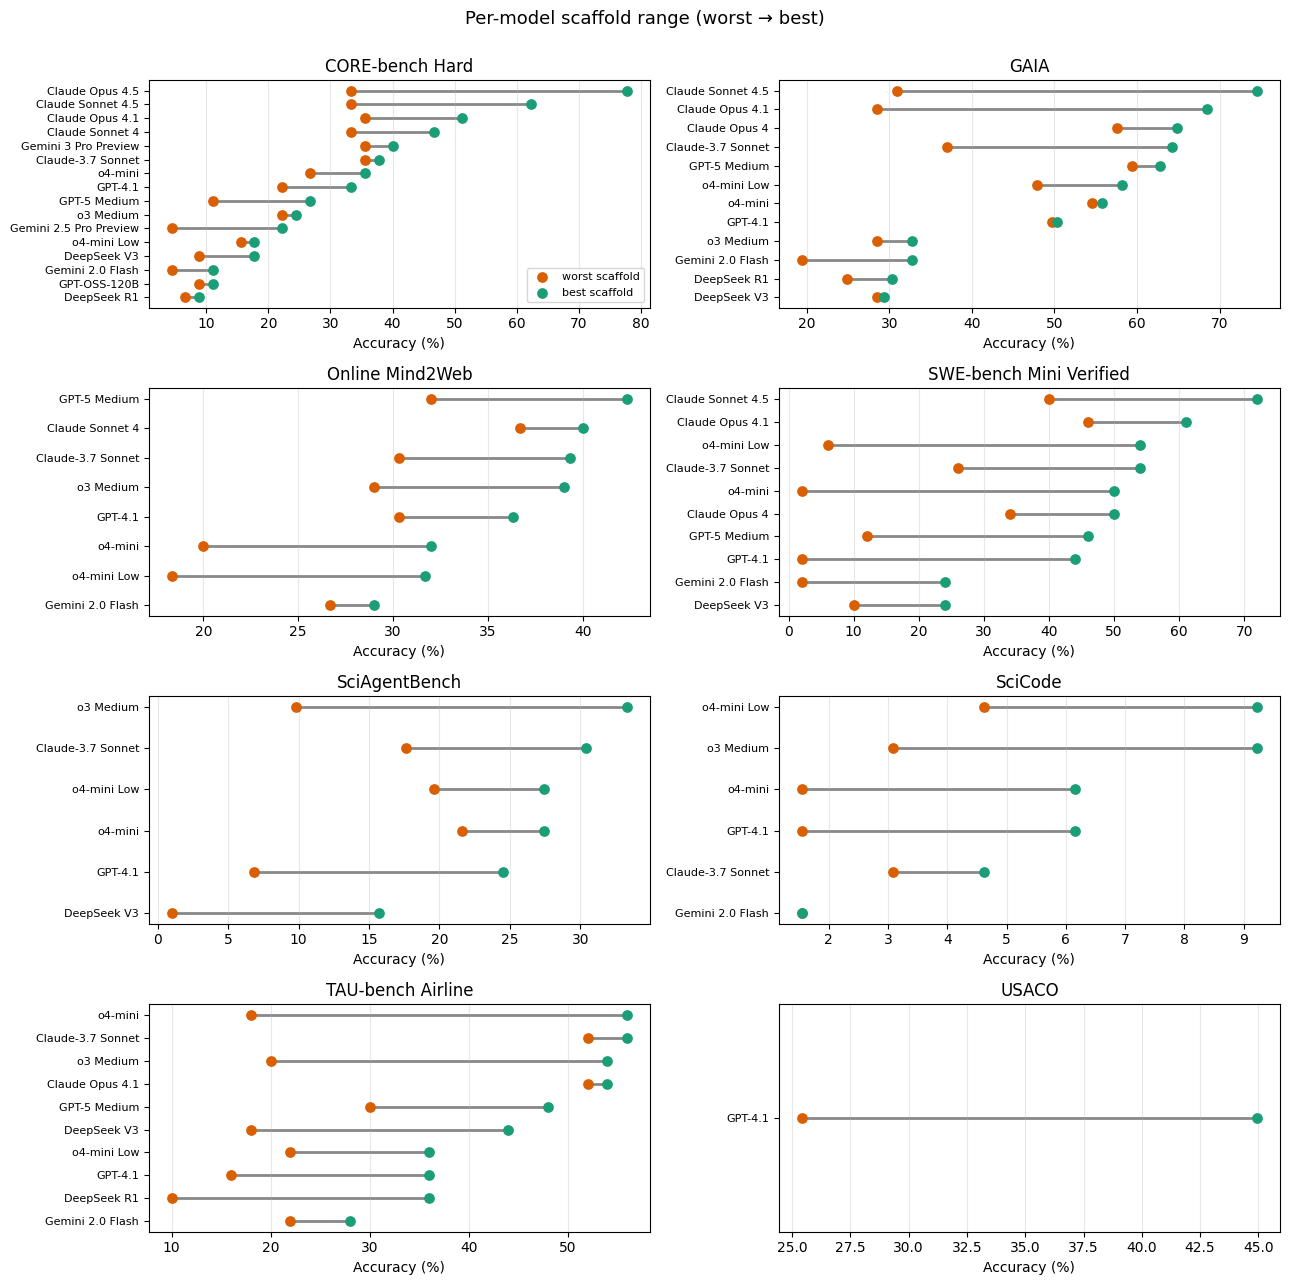

In [4]:
def dumbbell(ax, df_b, title):
    grp = df_b.groupby("model_norm")["accuracy"]
    n = grp.count()
    keep = n[n >= 2].index
    sub = df_b[df_b["model_norm"].isin(keep)]
    if sub.empty:
        ax.set_title(f"{title} (no models w/ >=2 scaffolds)")
        ax.axis("off")
        return
    agg = sub.groupby("model_norm")["accuracy"].agg(["min", "max"]).sort_values("max")
    y = np.arange(len(agg))
    ax.hlines(y, agg["min"], agg["max"], color="#888", lw=2, zorder=1)
    ax.scatter(agg["min"], y, color="#d95f02", s=45, zorder=2, label="worst scaffold")
    ax.scatter(agg["max"], y, color="#1b9e77", s=45, zorder=2, label="best scaffold")
    ax.set_yticks(y)
    ax.set_yticklabels(agg.index, fontsize=8)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)

useful = [b for b in long["benchmark"].unique()
          if (long[long["benchmark"] == b].groupby("model_norm")["scaffold"].nunique() >= 2).any()]
useful = sorted(useful)
ncols = 2
nrows = int(np.ceil(len(useful) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
axes = np.atleast_2d(axes).flatten()
for ax, b in zip(axes, useful):
    dumbbell(ax, long[long["benchmark"] == b], b)
for ax in axes[len(useful):]:
    ax.axis("off")
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Per-model scaffold range (worst → best)", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Rank slope graph between scaffold pairs

Each line is a model. Y position on left = rank under scaffold A, on right = rank under scaffold B. Crossings = rank reversals. One panel per benchmark, only the scaffold pair with the most shared models.

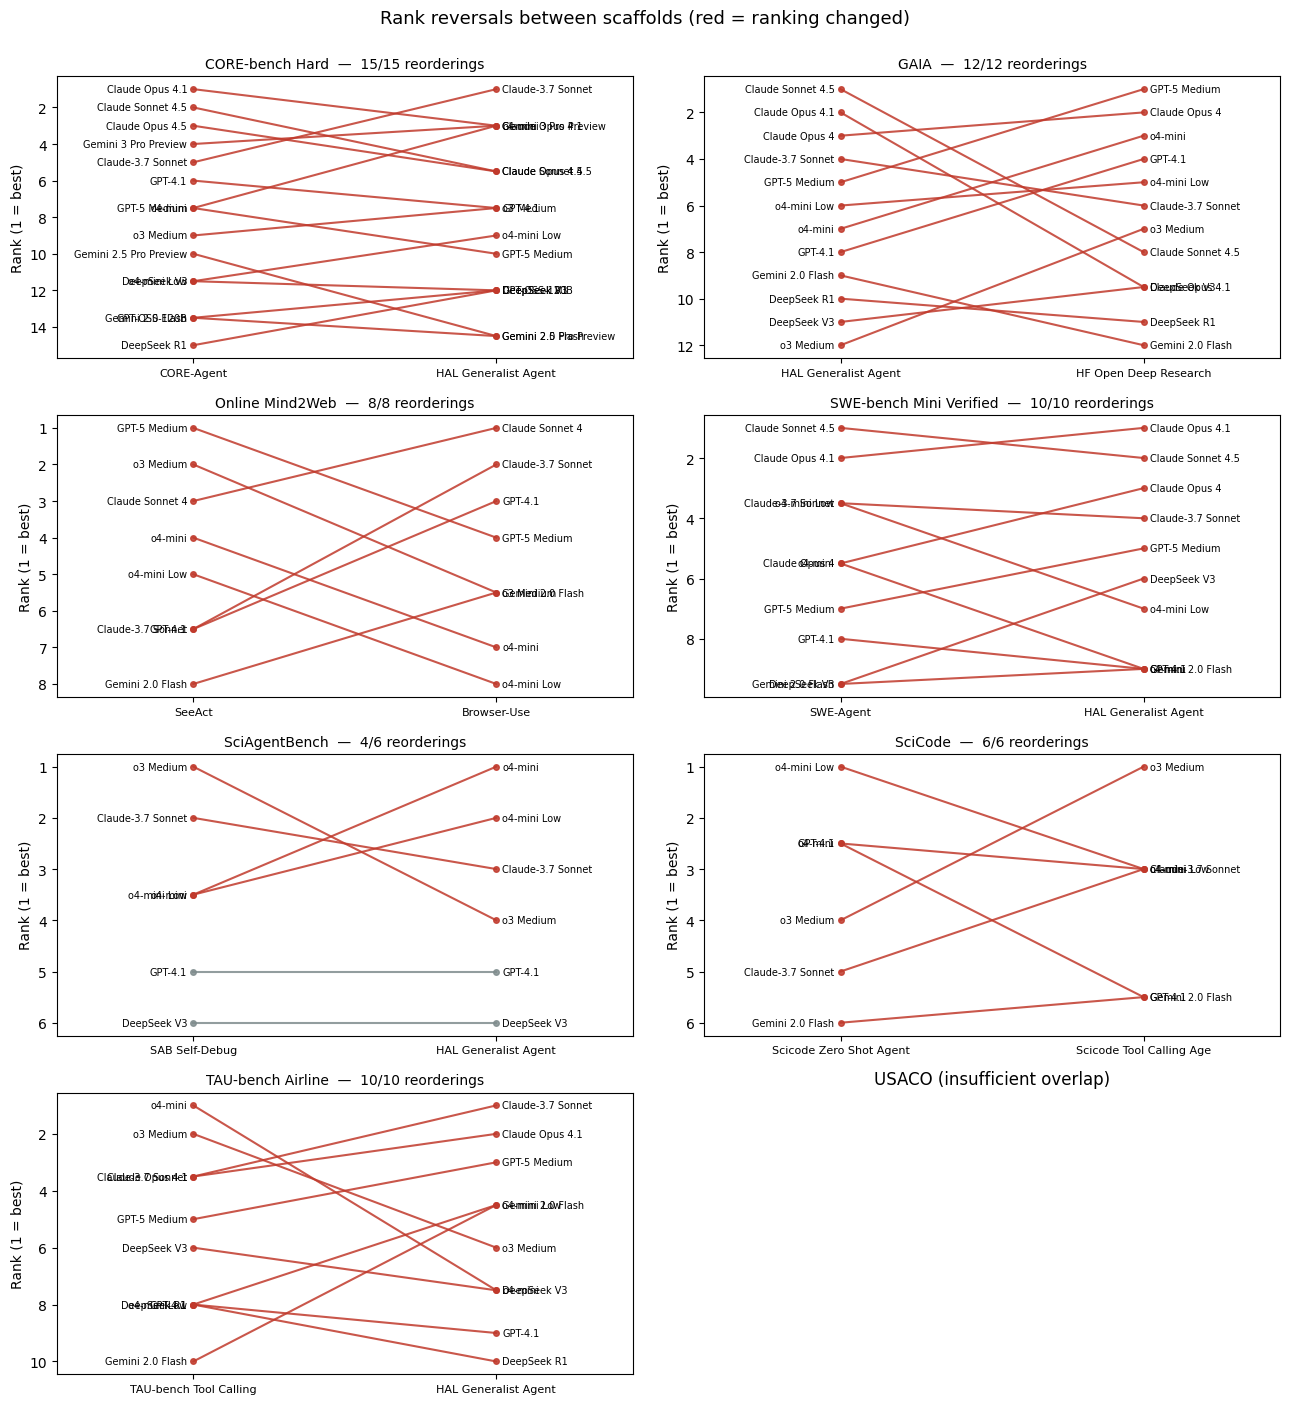

In [5]:
def best_scaffold_pair(df_b):
    scs = df_b["scaffold"].unique()
    best, best_n = None, 0
    for i in range(len(scs)):
        for j in range(i + 1, len(scs)):
            a = set(df_b[df_b["scaffold"] == scs[i]]["model_norm"])
            b = set(df_b[df_b["scaffold"] == scs[j]]["model_norm"])
            shared = a & b
            if len(shared) > best_n:
                best = (scs[i], scs[j], shared)
                best_n = len(shared)
    return best

def slope_panel(ax, df_b, title):
    pair = best_scaffold_pair(df_b)
    if pair is None or len(pair[2]) < 3:
        ax.set_title(f"{title} (insufficient overlap)")
        ax.axis("off")
        return
    s1, s2, shared = pair
    shared_idx = sorted(shared)
    d1 = df_b[(df_b["scaffold"] == s1) & (df_b["model_norm"].isin(shared))].set_index("model_norm")["accuracy"].reindex(shared_idx)
    d2 = df_b[(df_b["scaffold"] == s2) & (df_b["model_norm"].isin(shared))].set_index("model_norm")["accuracy"].reindex(shared_idx)
    r1 = d1.rank(ascending=False)
    r2 = d2.rank(ascending=False)
    n_swap = 0
    for m in shared_idx:
        swap = r1[m] != r2[m]
        n_swap += int(swap)
        ax.plot([0, 1], [r1[m], r2[m]],
                color="#c0392b" if swap else "#7f8c8d",
                lw=1.5, alpha=0.85, marker="o", markersize=4)
        ax.text(-0.02, r1[m], m, ha="right", va="center", fontsize=7)
        ax.text(1.02, r2[m], m, ha="left",  va="center", fontsize=7)
    ax.invert_yaxis()
    ax.set_xticks([0, 1])
    ax.set_xticklabels([s1[:24], s2[:24]], fontsize=8)
    ax.set_xlim(-0.45, 1.45)
    ax.set_ylabel("Rank (1 = best)")
    ax.set_title(f"{title}  —  {n_swap}/{len(shared_idx)} reorderings", fontsize=10)

panels = [b for b in useful]
ncols = 2
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows))
axes = np.atleast_2d(axes).flatten()
for ax, b in zip(axes, panels):
    slope_panel(ax, long[long["benchmark"] == b], b)
for ax in axes[len(panels):]:
    ax.axis("off")
fig.suptitle("Rank reversals between scaffolds (red = ranking changed)", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()


## 4. "Cost of the wrong scaffold"

Pick a target accuracy per benchmark (median achievable score). For each (model), compare the cheapest scaffold that hits the target to the cheapest scaffold overall. Bar height = $$ multiplier you pay for guessing wrong.

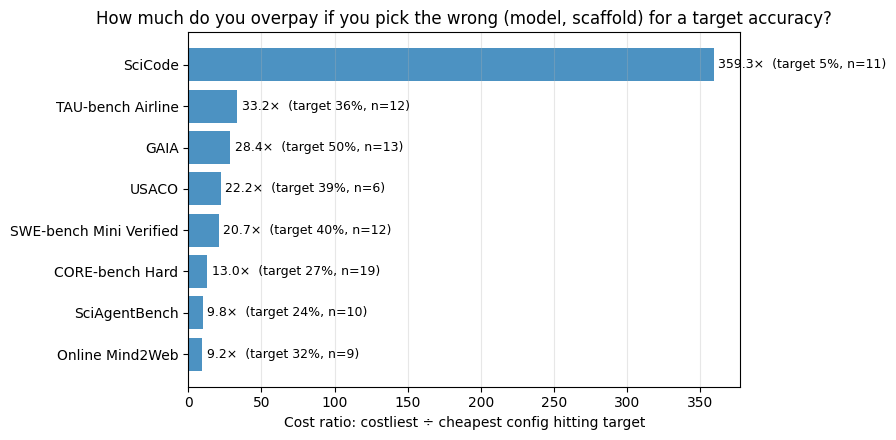

In [6]:
rows = []
for b in long["benchmark"].unique():
    sub = long[(long["benchmark"] == b) & long["cost"].notna()]
    if sub.empty:
        continue
    target = sub["accuracy"].median()  # target = median accuracy on this benchmark
    hit = sub[sub["accuracy"] >= target]
    if hit.empty:
        continue
    best  = hit["cost"].min()          # cheapest config that hits target
    worst = hit["cost"].max()          # most expensive config that *barely* hits target
    rows.append({"benchmark": b, "target_pct": target,
                 "cheapest_hit": best, "costliest_hit": worst,
                 "ratio": worst / best,
                 "n_configs": len(hit)})

cost_df = pd.DataFrame(rows).sort_values("ratio")

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(cost_df))
ax.barh(y, cost_df["ratio"], color="#2c7fb8", alpha=0.85)
for yi, r, t, n in zip(y, cost_df["ratio"], cost_df["target_pct"], cost_df["n_configs"]):
    ax.text(r + 0.5, yi, f" {r:.1f}×  (target {t:.0f}%, n={n})", va="center", fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(cost_df["benchmark"])
ax.set_xlabel("Cost ratio: costliest ÷ cheapest config hitting target")
ax.set_title("How much do you overpay if you pick the wrong (model, scaffold) for a target accuracy?")
ax.set_xlim(left=0)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Variance decomposition

Per benchmark, fit `logit_accuracy ~ C(model) + C(scaffold)` and report the share of variance attributable to model, scaffold, and residual (which includes interaction + noise). Single chart, one stacked bar per benchmark.

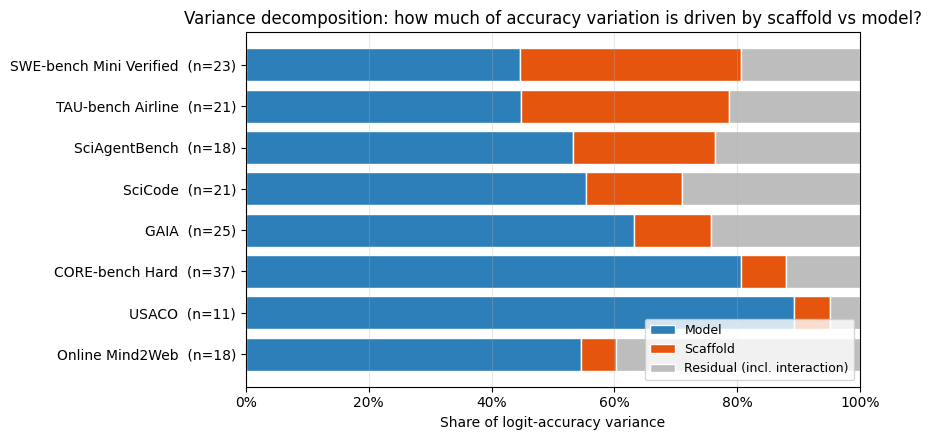

,model,scaffold,residual,n
benchmark,,,,
Online Mind2Web,0.546280,0.056346,0.397374,18
USACO,0.891913,0.059448,0.048639,11
CORE-bench Hard,0.806700,0.072979,0.120321,37
GAIA,0.631955,0.124873,0.243172,25
SciCode,0.553581,0.155739,0.290680,21
SciAgentBench,0.532337,0.230467,0.237196,18
TAU-bench Airline,0.448369,0.338335,0.213296,21
SWE-bench Mini Verified,0.445851,0.360701,0.193448,23


In [7]:
def variance_share(df_b):
    # need overlap: keep models/scaffolds with at least 2 obs each
    d = df_b.dropna(subset=["logit"]).copy()
    if d["model_norm"].nunique() < 2 or d["scaffold"].nunique() < 2:
        return None
    grand = d["logit"].mean()
    ss_tot = ((d["logit"] - grand) ** 2).sum()
    if ss_tot == 0:
        return None
    # one-way SS (Type I, sequential)
    model_means = d.groupby("model_norm")["logit"].transform("mean")
    ss_model = ((model_means - grand) ** 2).sum()
    resid_after_model = d["logit"] - model_means
    scaffold_means_resid = resid_after_model.groupby(d["scaffold"]).transform("mean")
    ss_scaffold = (scaffold_means_resid ** 2).sum()
    ss_resid = ss_tot - ss_model - ss_scaffold
    return {
        "model":    max(0, ss_model)    / ss_tot,
        "scaffold": max(0, ss_scaffold) / ss_tot,
        "residual": max(0, ss_resid)    / ss_tot,
        "n": len(d),
    }

rows = []
for b in sorted(long["benchmark"].unique()):
    v = variance_share(long[long["benchmark"] == b])
    if v:
        v["benchmark"] = b
        rows.append(v)
vdf = pd.DataFrame(rows).set_index("benchmark")
vdf = vdf.sort_values("scaffold")

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(vdf))
left = np.zeros(len(vdf))
for col, color, label in [("model",    "#2c7fb8", "Model"),
                          ("scaffold", "#e6550d", "Scaffold"),
                          ("residual", "#bdbdbd", "Residual (incl. interaction)")]:
    ax.barh(y, vdf[col], left=left, color=color, label=label, edgecolor="white")
    left += vdf[col].values
ax.set_yticks(y)
ax.set_yticklabels([f"{b}  (n={int(n)})" for b, n in zip(vdf.index, vdf["n"])])
ax.set_xlabel("Share of logit-accuracy variance")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Variance decomposition: how much of accuracy variation is driven by scaffold vs model?")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
vdf

## 6. Within-model harness deltas (the "Claude harness suspicious?" check)

For every model that appears in ≥2 scaffolds on the same benchmark, compute (accuracy on Claude Code / claude-style harness) − (best of the other harnesses). Group by model vendor. If Anthropic models systematically benefit more, bars cluster positive on the Anthropic side.

Claude-style scaffolds found: ['Claude Code']


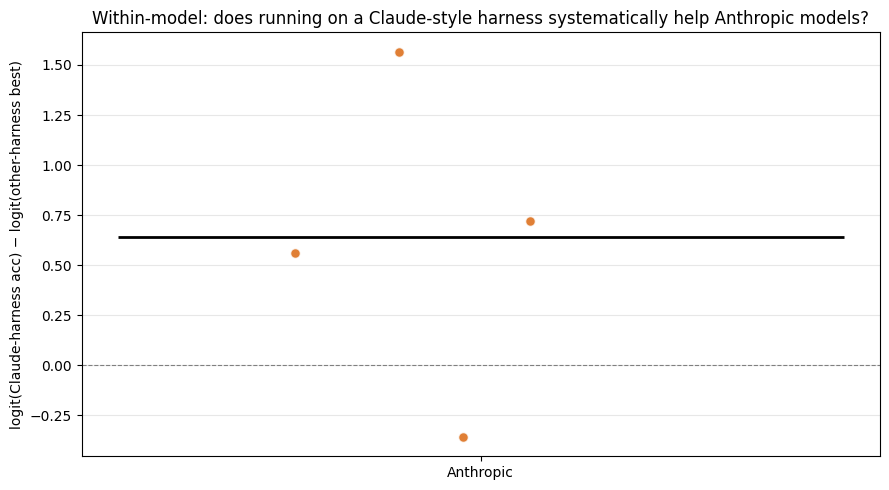

Per-vendor median delta (logit units):
            median      mean  count
vendor                             
Anthropic  0.64106  0.622651      4


In [8]:
def vendor_of(model_name):
    m = model_name.lower()
    if "claude" in m:        return "Anthropic"
    if "gpt" in m or "o1" in m or "o3" in m or "o4" in m: return "OpenAI"
    if "gemini" in m:        return "Google"
    if "llama" in m:         return "Meta"
    if "deepseek" in m:      return "DeepSeek"
    if "qwen" in m:          return "Alibaba"
    if "mistral" in m or "mixtral" in m: return "Mistral"
    return "Other"

def is_claude_harness(scaffold):
    s = scaffold.lower()
    return ("claude code" in s) or ("claude-code" in s) or ("anthropic" in s)

claude_scaffolds = sorted({s for s in long["scaffold"].dropna().unique() if is_claude_harness(s)})
print("Claude-style scaffolds found:", claude_scaffolds)

rows = []
for (b, m), g in long.groupby(["benchmark", "model_norm"]):
    cc = g[g["scaffold"].apply(is_claude_harness)]
    other = g[~g["scaffold"].apply(is_claude_harness)]
    if cc.empty or other.empty:
        continue
    delta = logit_score(cc["accuracy"].max()) - logit_score(other["accuracy"].max())
    rows.append({"benchmark": b, "model": m, "vendor": vendor_of(m),
                 "delta_logit": delta,
                 "cc_acc": cc["accuracy"].max(),
                 "other_acc": other["accuracy"].max()})
ddf = pd.DataFrame(rows)

if ddf.empty:
    print("No Claude-style scaffold rows overlap with non-Claude scaffolds in HAL data — plot skipped.")
else:
    order = ddf.groupby("vendor")["delta_logit"].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(9, 5))
    vendor_colors = {"Anthropic": "#d95f02", "OpenAI": "#1b9e77",
                     "Google": "#7570b3", "Meta": "#e7298a",
                     "DeepSeek": "#66a61e", "Alibaba": "#e6ab02",
                     "Mistral": "#a6761d", "Other": "#666"}
    for i, v in enumerate(order):
        sub = ddf[ddf["vendor"] == v]
        jitter = np.random.uniform(-0.18, 0.18, size=len(sub))
        ax.scatter(np.full(len(sub), i) + jitter, sub["delta_logit"],
                   color=vendor_colors.get(v, "#666"), alpha=0.8, s=50, edgecolor="white")
        ax.hlines(sub["delta_logit"].median(), i - 0.25, i + 0.25,
                  color="black", lw=2)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_ylabel("logit(Claude-harness acc) − logit(other-harness best)")
    ax.set_title("Within-model: does running on a Claude-style harness systematically help Anthropic models?")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Per-vendor median delta (logit units):")
    print(ddf.groupby("vendor")["delta_logit"].agg(["median", "mean", "count"]))

## 7. Scaffold efficiency: logit lift per order-of-magnitude spend

For each benchmark, pick the scaffold pair (A, B) with the most shared models. For every model in both:

- x axis: model's accuracy on scaffold A (baseline), logit-scaled
- y axis: (logit_B − logit_A) / log10($_B / $_A)

The denominator is the log-cost ratio so the metric is scale-invariant (a $10→$100 upgrade is treated the same as $100→$1000). Positive y = the more-expensive scaffold also delivers more accuracy (efficient upgrade). Negative y = paying more buys you less accuracy (inefficient — wrong direction). A nonzero slope vs x tells you whether the upgrade pays off more or less as the baseline model gets stronger.


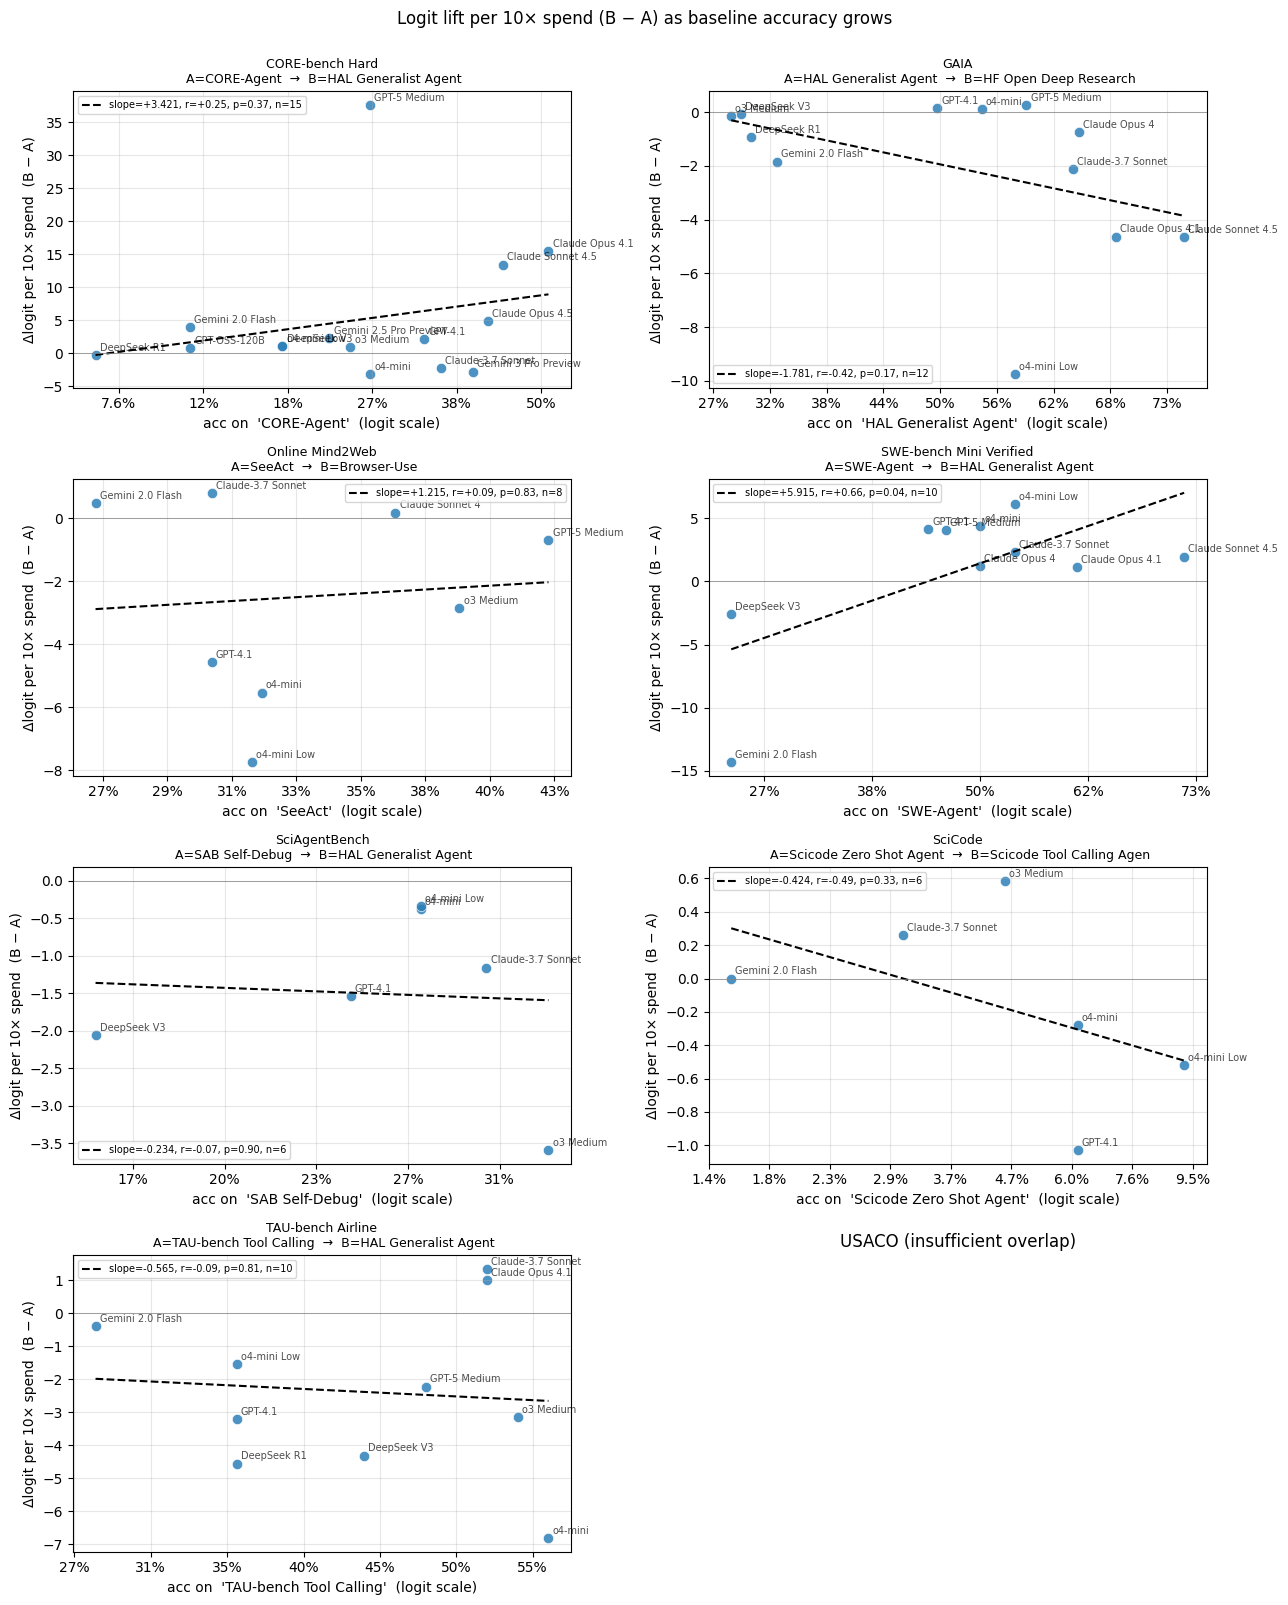

In [11]:
def efficiency_loglift_panel(ax, df_b, title):
    pair = best_scaffold_pair(df_b)
    if pair is None or len(pair[2]) < 3:
        ax.set_title(f"{title} (insufficient overlap)")
        ax.axis("off")
        return None
    s1, s2, shared = pair
    sub = df_b[df_b["model_norm"].isin(shared)].dropna(subset=["cost"])
    sub = sub[sub["cost"] > 0]
    pts = []
    for m in sorted(shared):
        a = sub[(sub["model_norm"] == m) & (sub["scaffold"] == s1)]
        b = sub[(sub["model_norm"] == m) & (sub["scaffold"] == s2)]
        if a.empty or b.empty:
            continue
        la, lb = logit_score(a["accuracy"].iloc[0]), logit_score(b["accuracy"].iloc[0])
        ca, cb = a["cost"].iloc[0], b["cost"].iloc[0]
        log_ratio = np.log10(cb / ca)
        if abs(log_ratio) < 1e-6:
            continue  # same cost, undefined
        pts.append({"model": m, "x": la, "y": (lb - la) / log_ratio,
                    "log_ratio": log_ratio,
                    "acc_a": a["accuracy"].iloc[0], "acc_b": b["accuracy"].iloc[0]})
    if len(pts) < 3:
        ax.set_title(f"{title} (n<3)")
        ax.axis("off")
        return None
    pdf = pd.DataFrame(pts)
    ax.scatter(pdf["x"], pdf["y"], color="#2c7fb8", s=55, alpha=0.85,
               edgecolor="white", linewidth=0.5)
    for _, r in pdf.iterrows():
        ax.annotate(r["model"], (r["x"], r["y"]),
                    fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
    slope, intercept = np.polyfit(pdf["x"], pdf["y"], 1)
    r, p = pearsonr(pdf["x"], pdf["y"])
    xs = np.linspace(pdf["x"].min(), pdf["x"].max(), 50)
    ax.plot(xs, slope * xs + intercept, color="black", lw=1.5, ls="--",
            label=f"slope={slope:+.3f}, r={r:+.2f}, p={p:.2f}, n={len(pdf)}")
    ax.legend(loc="best", fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)
    ax.xaxis.set_major_formatter(pct_formatter())
    ax.set_xlabel(f"acc on  '{s1[:30]}'  (logit scale)")
    ax.set_ylabel("Δlogit per 10× spend  (B − A)")
    ax.set_title(f"{title}\n A={s1[:25]}  →  B={s2[:25]}", fontsize=9)
    ax.grid(alpha=0.3)
    return pdf

useful_cost = [b for b in useful
               if long[(long["benchmark"] == b) & long["cost"].notna()]["scaffold"].nunique() >= 2]
ncols = 2
nrows = int(np.ceil(len(useful_cost) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.0 * nrows))
axes = np.atleast_2d(axes).flatten()
for ax, b in zip(axes, useful_cost):
    efficiency_loglift_panel(ax, long[long["benchmark"] == b], b)
for ax in axes[len(useful_cost):]:
    ax.axis("off")
fig.suptitle("Logit lift per 10× spend (B − A) as baseline accuracy grows", y=1.0, fontsize=12)
plt.tight_layout()
plt.show()


## 8. Score correlation across scaffold pairs (raw logit axes)

Same content as `score_correlation_summary.png` but axes are labeled in raw logit units (not percent). Useful when the linear OLS fit is the object of interest — a slope of 1 in logit-logit space means a fixed odds-multiplier between scaffolds across all models.

Red dashed = OLS fit; gray dotted = y = x reference.

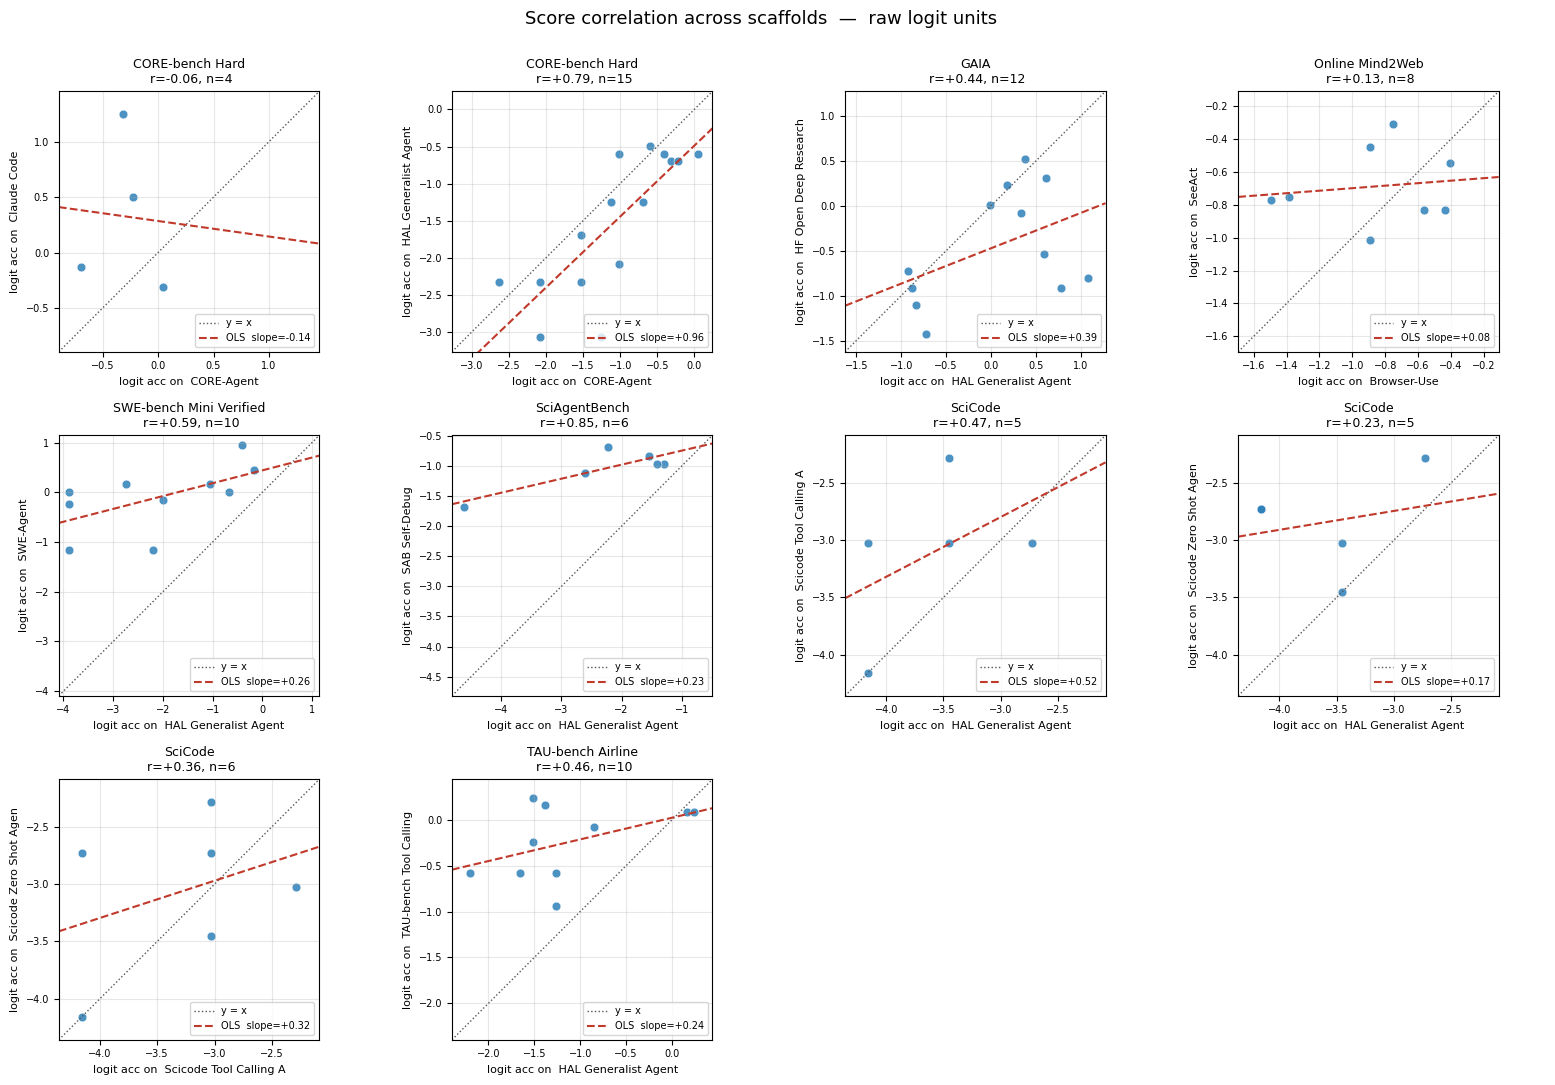

,benchmark,A,B,n,r,p,slope,intercept
5,SciAgentBench,HAL Generalist Agent,SAB Self-Debug,6,0.848491,0.032693,0.233173,-0.513535
1,CORE-bench Hard,CORE-Agent,HAL Generalist Agent,15,0.788309,0.000480,0.956396,-0.488798
4,SWE-bench Mini Verified,HAL Generalist Agent,SWE-Agent,10,0.591909,0.071434,0.258269,0.440129
6,SciCode,HAL Generalist Agent,Scicode Tool Calling Agent,5,0.465749,0.429188,0.521725,-1.233397
9,TAU-bench Airline,HAL Generalist Agent,TAU-bench Tool Calling,10,0.456541,0.184732,0.236093,0.022625
2,GAIA,HAL Generalist Agent,HF Open Deep Research,12,0.444698,0.147477,0.393683,-0.472620
8,SciCode,Scicode Tool Calling Agent,Scicode Zero Shot Agent,6,0.362898,0.479549,0.324907,-1.995863
7,SciCode,HAL Generalist Agent,Scicode Zero Shot Agent,5,0.229857,0.709935,0.165132,-2.250102
3,Online Mind2Web,Browser-Use,SeeAct,8,0.134172,0.751430,0.076268,-0.622484
0,CORE-bench Hard,CORE-Agent,Claude Code,4,-0.060285,0.939715,-0.140138,0.284611


In [12]:
pairs = []
for b in sorted(long["benchmark"].unique()):
    df_b = long[long["benchmark"] == b]
    scs = sorted(df_b["scaffold"].dropna().unique())
    for i in range(len(scs)):
        for j in range(i + 1, len(scs)):
            s1, s2 = scs[i], scs[j]
            d1 = df_b[df_b["scaffold"] == s1].set_index("model_norm")["accuracy"]
            d2 = df_b[df_b["scaffold"] == s2].set_index("model_norm")["accuracy"]
            shared = sorted(set(d1.index) & set(d2.index))
            if len(shared) < 4:
                continue
            x = logit_score(d1.loc[shared].values)
            y = logit_score(d2.loc[shared].values)
            mask = np.isfinite(x) & np.isfinite(y)
            x, y = x[mask], y[mask]
            shared_m = [m for m, k in zip(shared, mask) if k]
            if len(x) < 4:
                continue
            r, pval = pearsonr(x, y)
            slope, intercept = np.polyfit(x, y, 1)
            pairs.append({"benchmark": b, "s1": s1, "s2": s2,
                          "x": x, "y": y, "models": shared_m,
                          "r": r, "p": pval, "slope": slope, "intercept": intercept})

ncols = 4
nrows = int(np.ceil(len(pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.6 * nrows))
axes = np.atleast_2d(axes).flatten()

for ax, pr in zip(axes, pairs):
    ax.scatter(pr["x"], pr["y"], color="#2c7fb8", s=40, alpha=0.85,
               edgecolor="white", linewidth=0.5)
    lo = min(pr["x"].min(), pr["y"].min()) - 0.2
    hi = max(pr["x"].max(), pr["y"].max()) + 0.2
    ax.plot([lo, hi], [lo, hi], color="#555", ls=":", lw=1, label="y = x")
    xs = np.linspace(lo, hi, 50)
    ax.plot(xs, pr["slope"] * xs + pr["intercept"], color="#c0392b", ls="--", lw=1.5,
            label=f"OLS  slope={pr['slope']:+.2f}")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"logit acc on  {pr['s1'][:22]}", fontsize=8)
    ax.set_ylabel(f"logit acc on  {pr['s2'][:22]}", fontsize=8)
    ax.set_title(f"{pr['benchmark']}\n r={pr['r']:+.2f}, n={len(pr['x'])}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

for ax in axes[len(pairs):]:
    ax.axis("off")

fig.suptitle("Score correlation across scaffolds  —  raw logit units", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

# summary table
summary = pd.DataFrame([{"benchmark": p["benchmark"], "A": p["s1"], "B": p["s2"],
                        "n": len(p["x"]), "r": p["r"], "p": p["p"],
                        "slope": p["slope"], "intercept": p["intercept"]} for p in pairs])
summary.sort_values("r", ascending=False)


## 9. Scaffolding impact vs Epoch Capabilities Index — per benchmark

Same idea but separated by benchmark, each panel with its own OLS fit. Bottom-right panel summarizes the per-benchmark slopes side-by-side so you can see at a glance which benchmarks show "scaffold washes out" (negative slope) vs "scaffold compounds with capability" (positive slope).

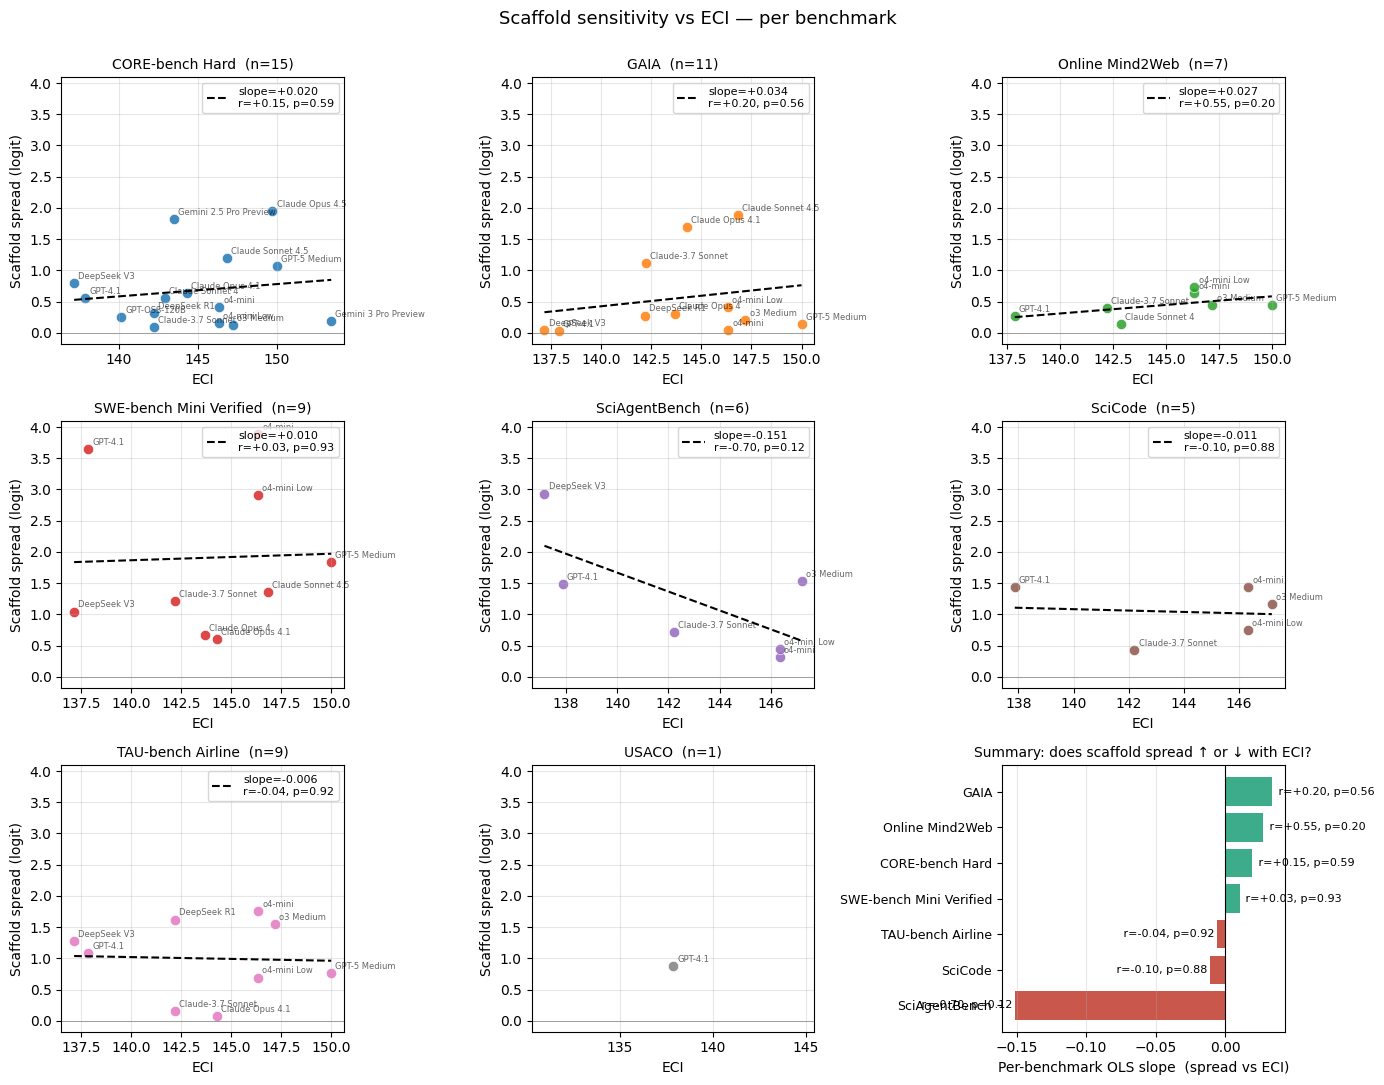


Per-benchmark fits:
              benchmark  n     slope  intercept         r        p
        CORE-bench Hard 15  0.019712  -2.176920  0.150786 0.591673
                   GAIA 11  0.033680  -4.291029  0.195624 0.564305
        Online Mind2Web  7  0.027476  -3.538404  0.551270 0.199599
SWE-bench Mini Verified  9  0.010421   0.407314  0.034806 0.929166
          SciAgentBench  6 -0.151448  22.870430 -0.695859 0.124686
                SciCode  5 -0.011062   2.631091 -0.097701 0.875801
      TAU-bench Airline  9 -0.005895   1.845357 -0.041046 0.916498
                  USACO  1       NaN        NaN       NaN      NaN


In [14]:
eci_df = pd.read_csv("epoch_benchmark_data/epoch_capabilities_index.csv")
eci_df["Model name"] = eci_df["Model name"].astype(str).str.strip()
eci_lookup_raw = eci_df.groupby("Model name")["ECI Score"].mean()

def normalize_for_match(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s*\(.*?\)", "", s)
    s = re.sub(r"[-_]", " ", s)
    s = re.sub(r"\s+(medium|low|high|preview|xhigh|pareto optimal)\b", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

eci_norm = {normalize_for_match(k): v for k, v in eci_lookup_raw.items()}
manual = {
    "deepseek v3":   eci_lookup_raw.get("DeepSeek-V3", np.nan),
    "deepseek v3.1": eci_lookup_raw.get("DeepSeek-V3 (Mar 2025)", eci_lookup_raw.get("DeepSeek-V3", np.nan)),
    "deepseek r1":   eci_lookup_raw.get("DeepSeek-R1", np.nan),
    "gpt 5":         eci_lookup_raw.get("GPT-5", np.nan),
    "gpt oss 120b":  eci_lookup_raw.get("gpt-oss-120b", np.nan),
    "gemini 2.5 pro": eci_lookup_raw.get("Gemini 2.5 Pro (Jun 2025)",
                       eci_lookup_raw.get("Gemini 2.5 Pro (May 2025)", np.nan)),
    "gemini 3 pro":  eci_lookup_raw.get("Gemini 3 Pro", np.nan),
    "o3":            eci_lookup_raw.get("o3", np.nan),
    "o4 mini":       eci_lookup_raw.get("o4-mini", np.nan),
    "claude 3.7 sonnet": eci_lookup_raw.get("Claude 3.7 Sonnet", np.nan),
}
for k, v in manual.items():
    if pd.notna(v):
        eci_norm.setdefault(k, v)
def eci_for(m): return eci_norm.get(normalize_for_match(m), np.nan)

grp = long.groupby(["benchmark", "model_norm"])["logit"]
spread_df = (grp.max() - grp.min()).rename("spread").reset_index()
spread_df["n_scaff"] = grp.count().values
spread_df = spread_df[spread_df["n_scaff"] >= 2].copy()
spread_df["eci"] = spread_df["model_norm"].apply(eci_for)
matched = spread_df.dropna(subset=["eci"]).copy()

# per-benchmark fits
benches = sorted(matched["benchmark"].unique())
fit_rows = []
for b in benches:
    sub = matched[matched["benchmark"] == b]
    if len(sub) < 3:
        fit_rows.append({"benchmark": b, "n": len(sub), "slope": np.nan, "r": np.nan, "p": np.nan})
        continue
    slope, intercept = np.polyfit(sub["eci"], sub["spread"], 1)
    r, pval = pearsonr(sub["eci"], sub["spread"])
    fit_rows.append({"benchmark": b, "n": len(sub),
                     "slope": slope, "intercept": intercept, "r": r, "p": pval})
fits = pd.DataFrame(fit_rows)

# layout: per-benchmark panels + one summary panel
n_panels = len(benches) + 1
ncols = 3
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.6 * nrows))
axes = np.atleast_2d(axes).flatten()

# global y limits to keep panels comparable
y_lo, y_hi = matched["spread"].min() - 0.2, matched["spread"].max() + 0.2

cmap = plt.get_cmap("tab10")
for i, b in enumerate(benches):
    ax = axes[i]
    sub = matched[matched["benchmark"] == b]
    ax.scatter(sub["eci"], sub["spread"], color=cmap(i % 10),
               s=55, alpha=0.85, edgecolor="white", linewidth=0.5)
    for _, row in sub.iterrows():
        ax.annotate(row["model_norm"], (row["eci"], row["spread"]),
                    fontsize=6, alpha=0.6, xytext=(3, 3), textcoords="offset points")
    f = fits[fits["benchmark"] == b].iloc[0]
    if pd.notna(f["slope"]):
        xs = np.linspace(sub["eci"].min(), sub["eci"].max(), 50)
        ax.plot(xs, f["slope"] * xs + f["intercept"], color="black", lw=1.5, ls="--",
                label=f"slope={f['slope']:+.3f}\nr={f['r']:+.2f}, p={f['p']:.2f}")
        ax.legend(loc="best", fontsize=8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel("ECI")
    ax.set_ylabel("Scaffold spread (logit)")
    ax.set_title(f"{b}  (n={int(f['n'])})", fontsize=10)
    ax.grid(alpha=0.3)

# summary panel: per-benchmark slopes
ax = axes[len(benches)]
slope_df = fits.dropna(subset=["slope"]).sort_values("slope")
colors = ["#c0392b" if s < 0 else "#1b9e77" for s in slope_df["slope"]]
y = np.arange(len(slope_df))
ax.barh(y, slope_df["slope"], color=colors, alpha=0.85)
for yi, s, r, pval in zip(y, slope_df["slope"], slope_df["r"], slope_df["p"]):
    ax.text(s + (0.002 if s >= 0 else -0.002), yi,
            f" r={r:+.2f}, p={pval:.2f}",
            va="center", ha="left" if s >= 0 else "right", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(slope_df["benchmark"], fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Per-benchmark OLS slope  (spread vs ECI)")
ax.set_title("Summary: does scaffold spread ↑ or ↓ with ECI?", fontsize=10)
ax.grid(axis="x", alpha=0.3)

for ax in axes[n_panels:]:
    ax.axis("off")

fig.suptitle("Scaffold sensitivity vs ECI — per benchmark", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

print("\nPer-benchmark fits:")
print(fits.to_string(index=False))
